In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import datetime as dt
from bs4 import BeautifulSoup
import os
from matplotlib import font_manager
from PIL import Image
import matplotlib.font_manager as fm
import plotly.express as px
from collections import Counter
import emoji
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

# WhatsApp Chat Data Loading

> Step 1: Open the WhatsApp chat text file located at  
> `/kaggle/input/what-app-chat-data/whatapp_2.txt`  
>  
> Step 2: Read the entire content of the file into memory for processing

---

**Note:**  
This allows you to access and analyze the full chat data for insights and visualization.


In [2]:
font_path=fm.FontProperties(fname="/kaggle/input/elegant-and-functional-fonts/Ador Noirrit Web.otf")
mask=np.array(Image.open("/kaggle/input/wordcloud-mask-collection/twitter.png"))

In [3]:
f=open("/kaggle/input/what-app-chat-data/whatapp_2.txt")
df=f.read()

In [4]:
print(df)

5/8/19, 7:54 PM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
5/8/19, 7:35 PM - ~ Zobayer created group "CSE 46 (Male)"
5/8/19, 7:54 PM - +880 1875-278636 added you
5/8/19, 7:58 PM - +880 1875-278636 changed this group's icon
5/8/19, 7:57 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:01 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:02 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:02 PM - +880 1875-278636: <Media omitted>
5/8/19, 8:02 PM - +880 1

# WhatsApp Chat Data Parsing

- Extract messages by splitting raw chat text at date-time stamps using regex.
- Identify and collect all timestamps present in the chat.
- Output counts of total messages and timestamps for verification.

# Purpose

This step isolates each message with its timestamp, enabling further analysis of chat content and timing.


In [5]:

pattern = r'\d{1,2}/\d{1,2}/\d{2,4},\s+\d{1,2}:\d{2}\s*[AP]M\s+-\s+'

messages = re.split(pattern,df)[1:]

dates = re.findall(pattern,df)
print(f"Message Length : {len(messages)}")
print(f"Dates Length : {len(dates)}")

Message Length : 2495
Dates Length : 2495


# Extracting Date and Time from a Timestamp String

- Split the timestamp string by comma to separate date and time.
- Further split the time part to isolate the exact time, removing extra text.
- Print the extracted date and time in a clear format.

# Purpose

This process helps in parsing and formatting timestamp details for easier analysis and readability.


In [6]:
string = '16/08/18, 20:09 - '
string = string.split(',')
date,time = string[0],string[1]
time = time.split('-')
time = time[0].strip()
print(date+" and "+time)

16/08/18 and 20:09


# Function to Extract Date and Time from a Timestamp String

- Splits the input string by comma to separate date and time.
- Cleans and trims the time portion by splitting on '-' and removing extra spaces.
- Returns a formatted string combining date and time for consistent timestamp representation.


In [7]:
def gettimeanddate(string):
    
    string = string.split(',')
    date,time = string[0],string[1]
    time = time.split('-')
    time = time[0].strip()
    
    return date+" "+time

# Creating a DataFrame for WhatsApp Chat Analysis

- Combines extracted messages and their corresponding dates into a DataFrame.
- Applies the custom function to extract and format date and time into a single column.
- Removes the original raw date column to keep the DataFrame clean.
- Displays the first few rows to verify the data structure.


In [8]:
new_df=pd.DataFrame({"user_messages":messages,"message_date":dates})
new_df["Date"]=new_df["message_date"].apply(lambda text:gettimeanddate(text))
new_df.drop(columns=["message_date"],axis=1,inplace=True)
new_df.head()

,user_messages,Date
0,Messages and calls are end-to-end encrypted. O...,5/8/19 7:54 PM
1,"~ Zobayer created group ""CSE 46 (Male)""\n",5/8/19 7:35 PM
2,+880 1875-278636 added you\n,5/8/19 7:54 PM
3,+880 1875-278636 changed this group's icon\n,5/8/19 7:58 PM
4,+880 1875-278636: <Media omitted>\n,5/8/19 7:57 PM


# Extracting Users and Messages from Raw Chat Data

- Initialized empty lists `users` and `messages` to store extracted user names and messages.
- Iterated over each raw message in the `user_messages` column.
- Used regex split on the first colon and space (`": "`) to separate user names from messages.
- If split was successful, extracted the user and message; otherwise, labeled it as a `Group_Notification`.
- Added new columns `User` and `message` to the DataFrame based on the extracted information.
- Defined a helper function to retain only the first line of multi-line messages for cleaner display.
- Applied this function to the `message` column to remove any newline characters.
- Finally, dropped the original `user_messages` column as it was no longer needed.

This process structures the raw chat data into a clean, tabular format for easier analysis.


In [9]:
def extract_user_message(message):
    pattern = r'^([\w\s~+0-9\-()]+):\s'
    match = re.match(pattern, message)
    if match:
        user = match.group(1).capitalize()
        msg = message[match.end():].capitalize()
        return user, msg
    else:
        return "Group_notification", message.capitalize()


new_df[['User', 'Message']] = new_df['user_messages'].apply(lambda x: pd.Series(extract_user_message(x)))
new_df = new_df[['Message', 'Date', 'User']]

# Reorder and Rename Columns

- Rearranged columns to: `message`, `date`, `User` for logical flow.
- Renamed `message` to `Message` and `date` to `Date` to improve readability.
- Displayed the first few records to confirm changes.


In [10]:
new_df.head()

,Message,Date,User
0,Messages and calls are end-to-end encrypted. o...,5/8/19 7:54 PM,Group_notification
1,"~ zobayer created group ""cse 46 (male)""\n",5/8/19 7:35 PM,Group_notification
2,+880 1875-278636 added you\n,5/8/19 7:54 PM,Group_notification
3,+880 1875-278636 changed this group's icon\n,5/8/19 7:58 PM,Group_notification
4,<media omitted>\n,5/8/19 7:57 PM,+880 1875-278636


In [11]:
new_df.shape

(2495, 3)

# DateTime Processing and Feature Extraction

- Converted the `Date` column to datetime format using the specified pattern.
- Extracted additional time-based features for deeper analysis:
  - `Only date`: Date without time.
  - `Year`, `Month_num`, `Month`: Year and month details.
  - `Day`, `Day_name`: Day of the month and weekday name.
  - `Hour`, `Minute`: Time details to capture messaging patterns.
- Displayed the updated DataFrame with new temporal features.


In [12]:
# Convert Date column to datetime with specified format
date_format = '%m/%d/%y %I:%M %p' 
new_df['Date'] = pd.to_datetime(new_df['Date'], format=date_format)
new_df['Only date'] = new_df['Date'].dt.date
new_df['Year'] = new_df['Date'].dt.year
new_df['Month_num'] = new_df['Date'].dt.month
new_df['Month'] = new_df['Date'].dt.month_name()
new_df['Day'] = new_df['Date'].dt.day
new_df['Day_name'] = new_df['Date'].dt.day_name()
new_df['Hour'] = new_df['Date'].dt.hour
new_df['Minute'] = new_df['Date'].dt.minute 


new_df.head()

,Message,Date,User,Only date,Year,Month_num,Month,Day,Day_name,Hour,Minute
0,Messages and calls are end-to-end encrypted. o...,2019-05-08 19:54:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,54
1,"~ zobayer created group ""cse 46 (male)""\n",2019-05-08 19:35:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,35
2,+880 1875-278636 added you\n,2019-05-08 19:54:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,54
3,+880 1875-278636 changed this group's icon\n,2019-05-08 19:58:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,58
4,<media omitted>\n,2019-05-08 19:57:00,+880 1875-278636,2019-05-08,2019,5,May,8,Wednesday,19,57


In [13]:
words=[]

for message in new_df["Message"]:
    words.extend(message.split())
print(f"Length of Words : {len(words)}")

Length of Words : 13408


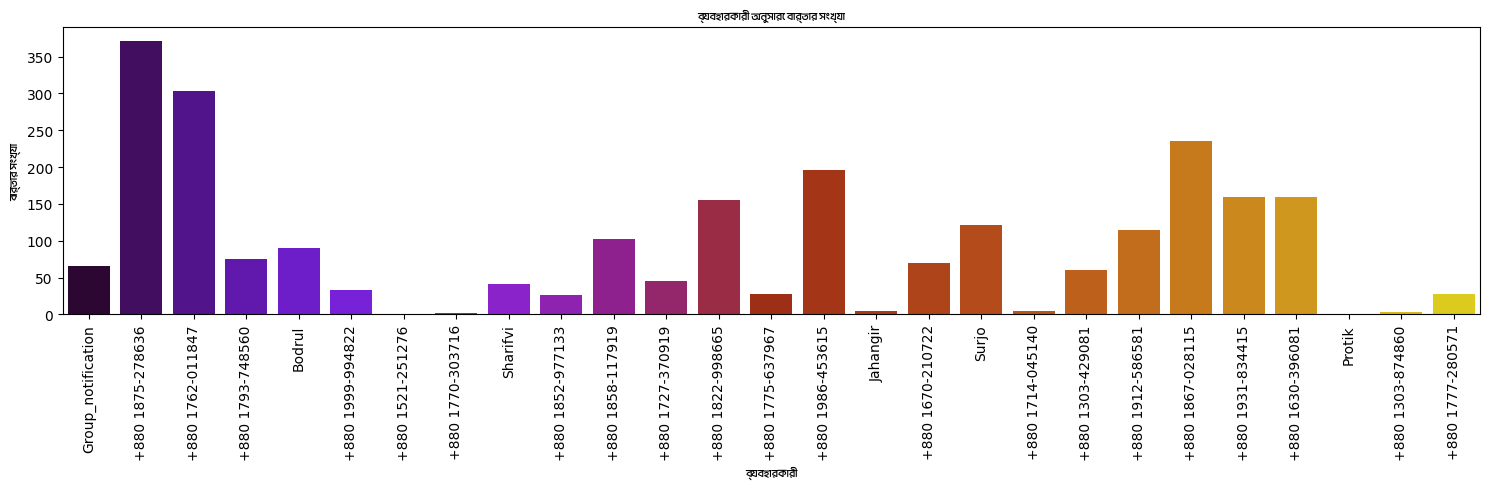

In [14]:
plt.figure(figsize=(15,5))
sns.countplot(data=new_df, x='User', palette='gnuplot')
plt.title('ব্যবহারকারী অনুসারে বার্তার সংখ্যা',fontproperties=font_path)
plt.xlabel('ব্যবহারকারী',fontproperties=font_path)
plt.ylabel('বার্তার সংখ্যা',fontproperties=font_path)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

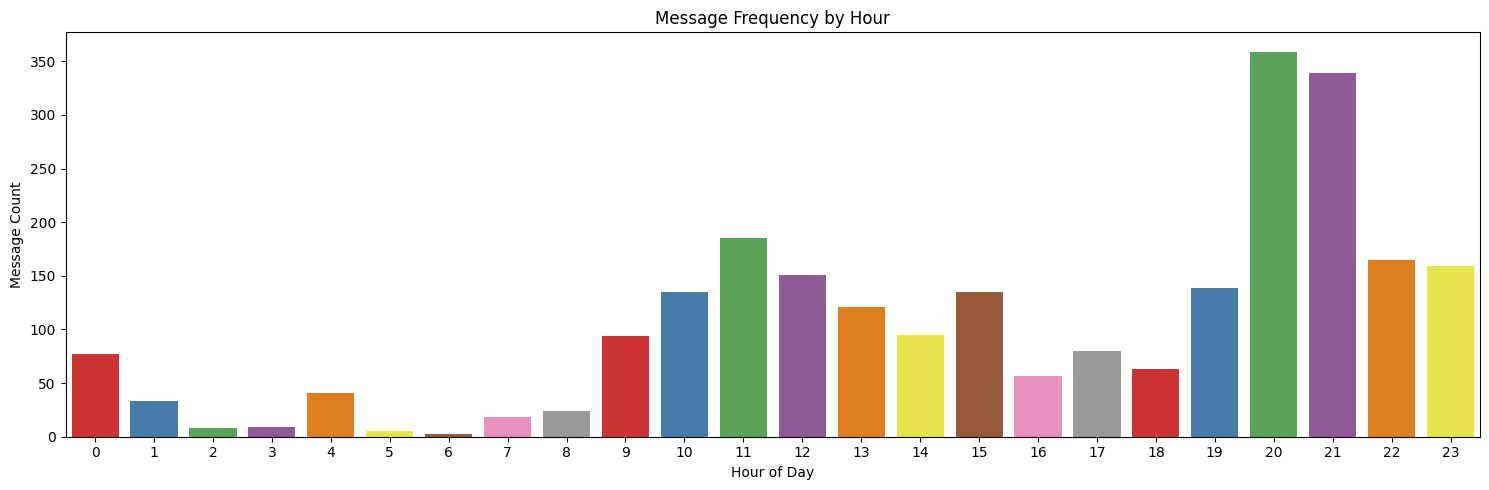

In [15]:
plt.figure(figsize=(15,5))
sns.countplot(data=new_df, x='Hour', palette='Set1')
plt.title('Message Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Message Count')
plt.tight_layout()
plt.show()

In [16]:
user_counts = new_df['User'].value_counts()
fig = px.pie(values=user_counts.values, names=user_counts.index, title='Proportion of Messages by User')
fig.update_layout(font_family="Noto Sans Bengali",width=1000,height=800)
fig.show()

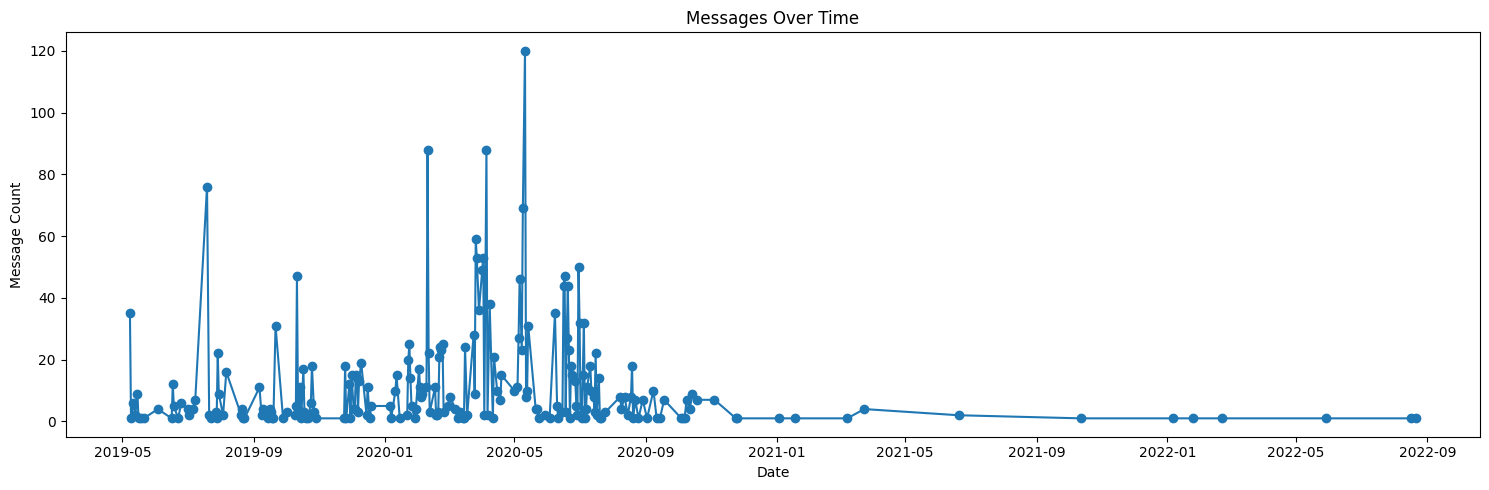

In [17]:
plt.figure(figsize=(15,5))
new_df.groupby('Only date').size().plot(kind='line', marker='o')
plt.title('Messages Over Time')
plt.xlabel('Date')
plt.ylabel('Message Count')
plt.tight_layout()
plt.show()

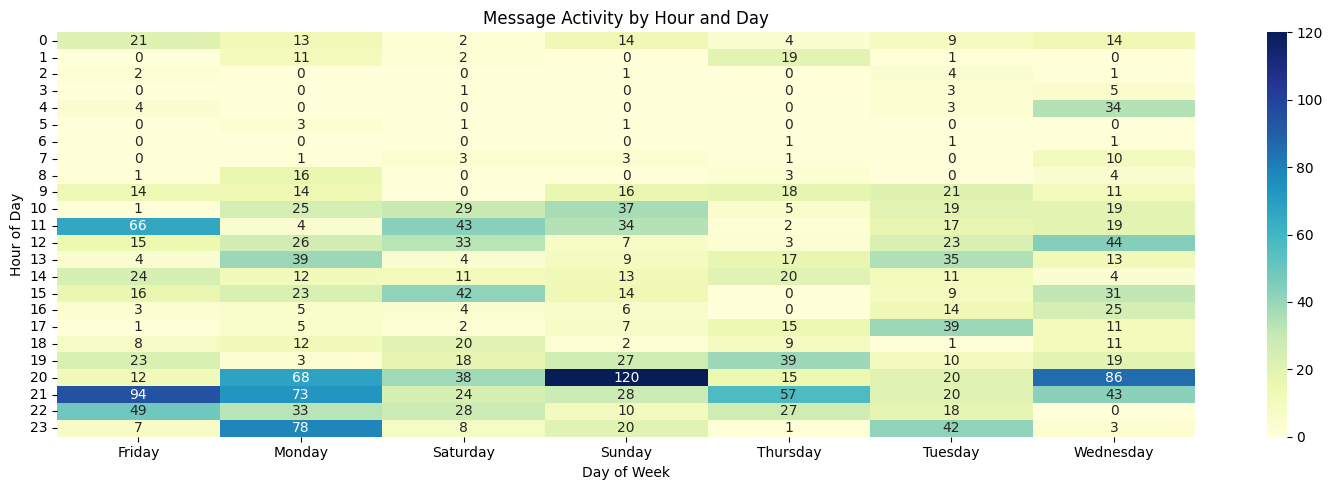

In [18]:
heatmap_data = new_df.pivot_table(index='Hour', columns='Day_name', values='Message', aggfunc='count', fill_value=0)
plt.figure(figsize=(15,5))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d')
plt.title('Message Activity by Hour and Day')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

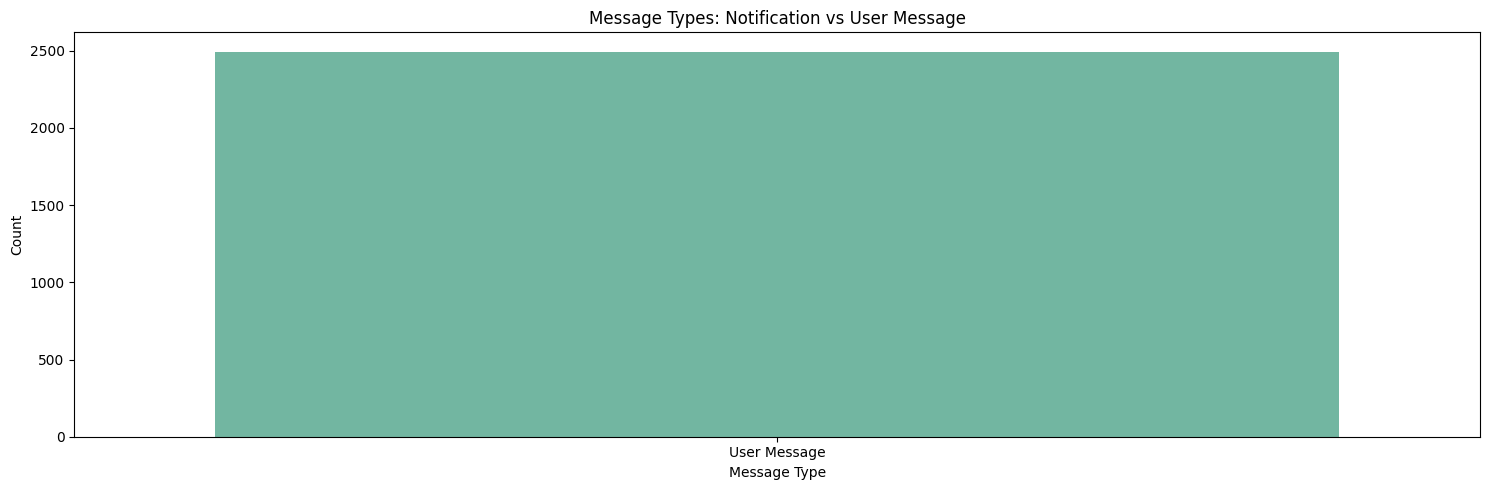

In [19]:
new_df['Message_Type'] = new_df['User'].apply(lambda x: 'Notification' if x == 'Group_Notification' else 'User Message')
plt.figure(figsize=(15,5))
sns.countplot(data=new_df, x='Message_Type', palette='Set2')
plt.title('Message Types: Notification vs User Message')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [20]:
new_df.head()

,Message,Date,User,Only date,Year,Month_num,Month,Day,Day_name,Hour,Minute,Message_Type
0,Messages and calls are end-to-end encrypted. o...,2019-05-08 19:54:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,54,User Message
1,"~ zobayer created group ""cse 46 (male)""\n",2019-05-08 19:35:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,35,User Message
2,+880 1875-278636 added you\n,2019-05-08 19:54:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,54,User Message
3,+880 1875-278636 changed this group's icon\n,2019-05-08 19:58:00,Group_notification,2019-05-08,2019,5,May,8,Wednesday,19,58,User Message
4,<media omitted>\n,2019-05-08 19:57:00,+880 1875-278636,2019-05-08,2019,5,May,8,Wednesday,19,57,User Message


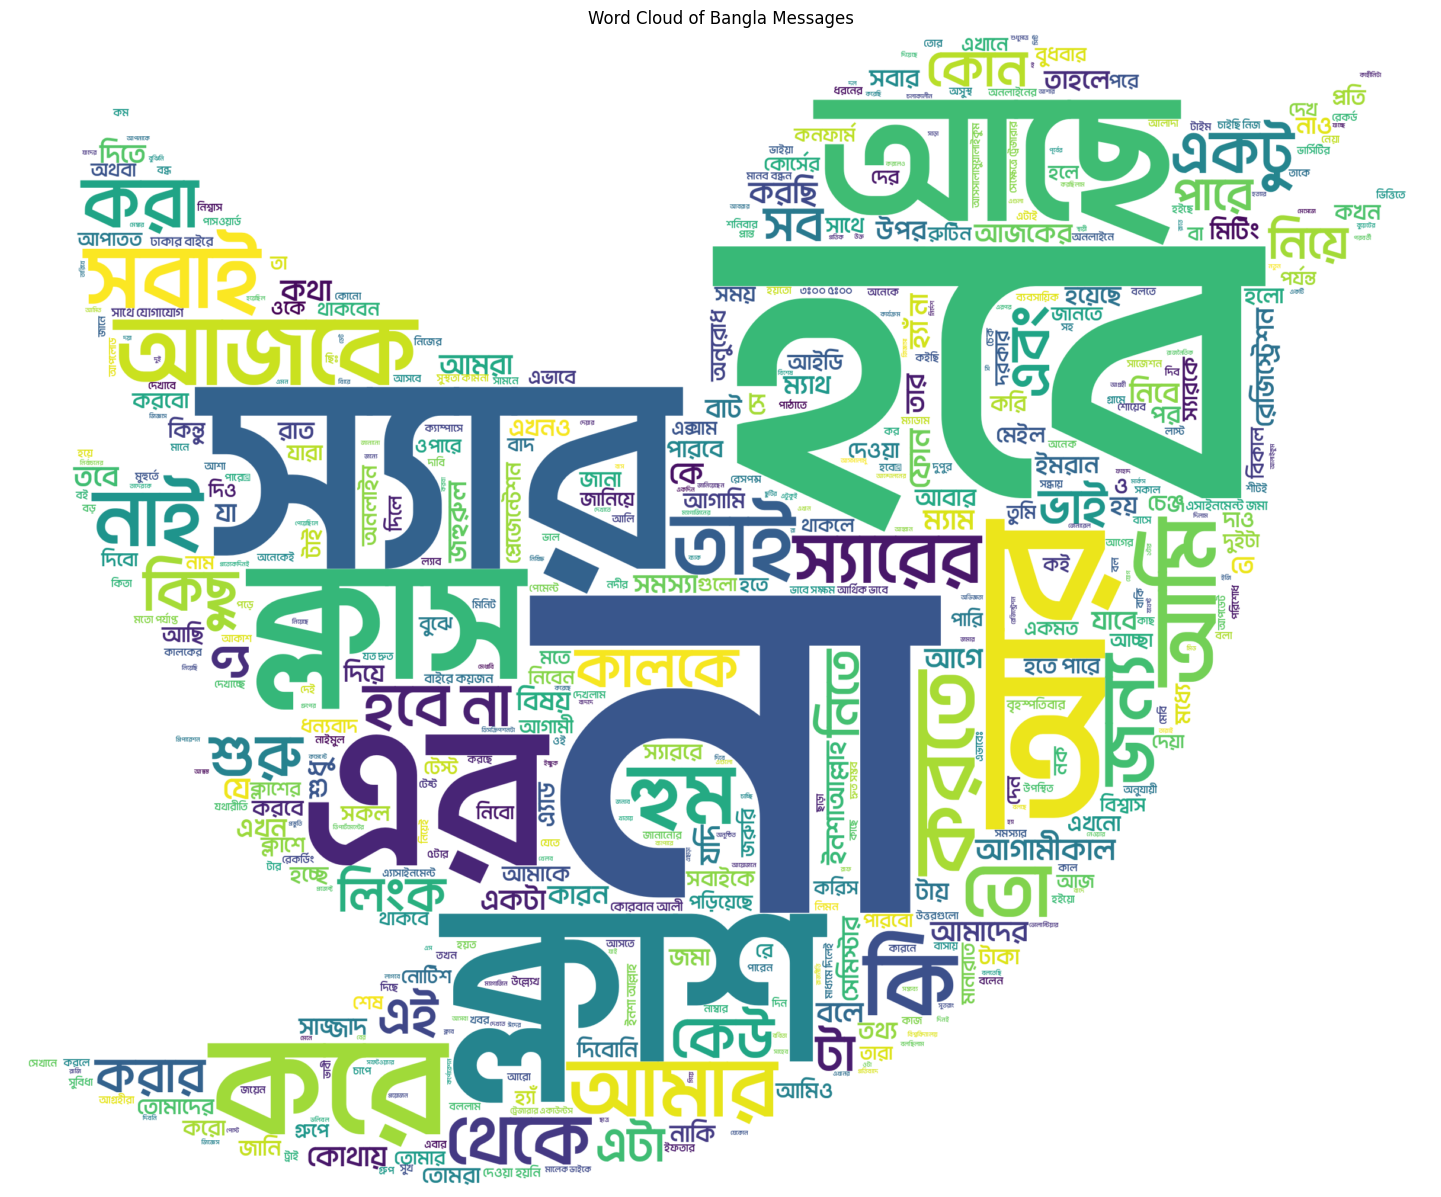

In [21]:
plt.figure(figsize=(20,15))
regex = r"[\u0980-\u09FF]+"
font="/kaggle/input/elegant-and-functional-fonts/Ador Noirrit Web.otf"
bangla_text = ' '.join(new_df[new_df['Message_Type'] == 'User Message']['Message'])
wordcloud = WordCloud(font_path=font,width=800, height=400, background_color='white',regexp=regex,mask=mask,max_words=500).generate(bangla_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Bangla Messages')
plt.show()

In [22]:
fig = px.scatter(new_df, x='Hour', y='Minute', color='User', 
                 size=new_df.groupby('Hour')['Message'].transform('count'),
                 hover_data=['Message', 'Date'], title='Messages by Hour and Minute')
fig.update_layout(font_family="Noto Sans Bengali", xaxis_title='Hour of Day', yaxis_title='Minute of Hour')
fig.show()

In [23]:
with open('/kaggle/input/elegant-and-functional-fonts/stopwords-bn.txt', 'r', encoding='utf-8-sig') as f:
    stop_word = f.read()
    stop_word = stop_word.replace(" ", "")
    stop_words = stop_word.split('\n')
    print(stop_words)

['অতএব', 'অথচ', 'অথবা', 'অনুযায়ী', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবধি', 'অবশ্য', 'অর্থাত', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আদ্যভাগে', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে', 'আমাদের', 'আমার', 'আমি', 'আর', 'আরও', 'ই', 'ইত্যাদি', 'ইহা', 'উচিত', 'উত্তর', 'উনি', 'উপর', 'উপরে', 'এ', 'এঁদের', 'এঁরা', 'এই', 'একই', 'একটি', 'একবার', 'একে', 'এক্', 'এখন', 'এখনও', 'এখানে', 'এখানেই', 'এটা', 'এটাই', 'এটি', 'এত', 'এতটাই', 'এতে', 'এদের', 'এব', 'এবং', 'এবার', 'এমন', 'এমনকী', 'এমনি', 'এর', 'এরা', 'এল', 'এস', 'এসে', 'ঐ', 'ও', 'ওঁদের', 'ওঁর', 'ওঁরা', 'ওই', 'ওকে', 'ওখানে', 'ওদের', 'ওর', 'ওরা', 'কখনও', 'কত', 'কবে', 'কমনে', 'কয়েক', 'কয়েকটি', 'করছে', 'করছেন', 'করতে', 'করবে', 'করবেন', 'করলে', 'করলেন', 'করা', 'করাই', 'করায়', 'করার', 'করি', 'করিতে', 'করিয়া', 'করিয়ে', 'করে', 'করেই', 'করেছিলেন', 'করেছে', 'করেছেন', 'করেন', 'কাউকে', 'কাছ', 'কাছে', 'কাজ', 'কাজে', 'কারও', 'কারণ', 'কি', 'কিংবা', 'কিছু', 'কিছুই', 'কিন্তু', 'কী', 'কে', 'কেউ', 'কেউই', 'কেখা', 'কেন', 'কোটি', 'কোন', 'কোনও'

In [24]:
def extract_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]

# Apply emoji extraction to each message
new_df['Emojis'] = new_df['Message'].apply(extract_emojis)

# Flatten the list of emojis and count them
all_emojis = [e for sublist in new_df['Emojis'] for e in sublist]
emoji_counts = Counter(all_emojis)

# Print the counts
if emoji_counts:
    for emj, count in emoji_counts.items():
        print(f"{emj}: {count}")
else:
    print("No emojis found in the messages.")

😫: 1
😂: 53
☝: 1
🥰: 12
👌: 10
😆: 19
🤣: 130
😎: 9
😻: 3
😒: 16
🤝: 3
🙂: 4
😁: 22
😪: 14
🤤: 1
🤔: 3
😑: 11
😶: 2
🙄: 49
😍: 18
🧐: 2
🥺: 3
😊: 4
☺: 3
✋: 4
👍: 14
😣: 6
😥: 3
🤪: 10
😃: 10
😄: 8
😇: 2
🤩: 4
🤓: 6
😏: 4
🙌: 1
😴: 5
😉: 3
🖐: 2
🥴: 9
✌: 3
🐸: 2
👀: 1
♥: 1
🏿: 1
🤨: 11
😀: 14
🥳: 1
😌: 8
😭: 19
😋: 1
😤: 5
☹: 3
😕: 4
😔: 2
😅: 1
😝: 4
🥱: 8
🤚: 2
🤟: 1
🏻: 1
🤦: 3
🤐: 4
🤧: 5
🖤: 3
❤: 3
😰: 2
🤬: 3
👉: 4
🏾: 4
🚾: 1
🏁: 1
⚽: 1
🌎: 1
🌚: 2
🤒: 3
😷: 3
🍜: 1
🥪: 3
😢: 4
😐: 1
😟: 2
💚: 2


In [25]:
def monthtimeline(selecteduser, df):
    if selecteduser != 'Overall':
        df = df[df['User'] == selecteduser]

    # Group by Year, Month_num, and Month name
    temp = df.groupby(['Year', 'Month_num', 'Month'])['Message'].count().reset_index()
    temp = temp.sort_values(by=['Year', 'Month_num'])

    # Create a new 'Time' column in format 'Month-Year'
    temp['Time'] = temp.apply(lambda row: f"{row['Month']}-{row['Year']}", axis=1)
    
    return temp

monthwise_df = monthtimeline('Overall', new_df)

In [26]:
monthwise_df.head()

,Year,Month_num,Month,Message,Time
0,2019,5,May,56,May-2019
1,2019,6,June,29,June-2019
2,2019,7,July,131,July-2019
3,2019,8,August,26,August-2019
4,2019,9,September,59,September-2019


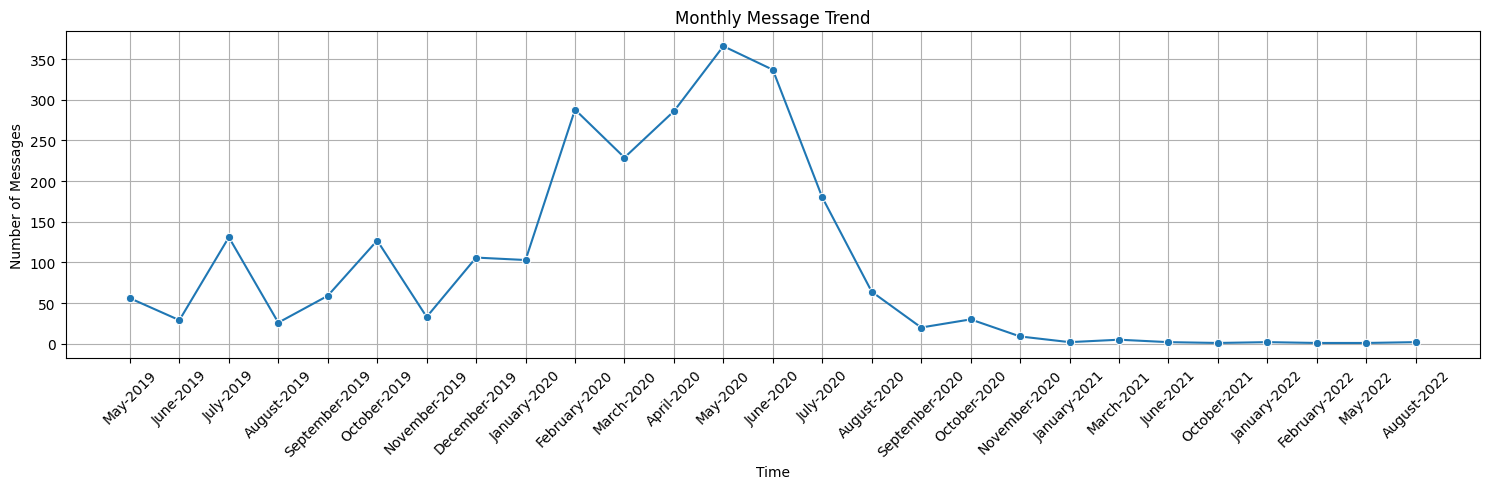

In [27]:
plt.figure(figsize=(15, 5))
sns.lineplot(data=monthwise_df, x='Time', y='Message', marker='o', sort=False)
plt.xticks(rotation=45)
plt.title('Monthly Message Trend')
plt.xlabel('Time')
plt.ylabel('Number of Messages')
plt.grid(True)
plt.tight_layout()
plt.show()


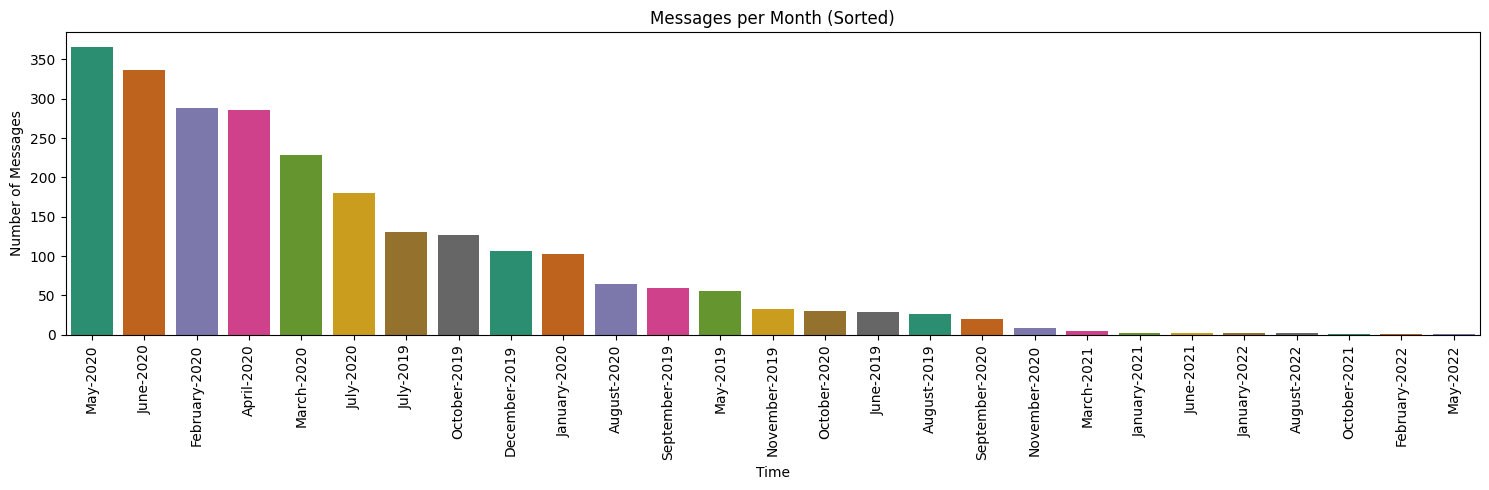

In [28]:
plt.figure(figsize=(15, 5))
sorted_df = monthwise_df.sort_values(by='Message', ascending=False)
sns.barplot(data=sorted_df, x='Time', y='Message', palette='Dark2')
plt.xticks(rotation=90)
plt.title('Messages per Month (Sorted)')
plt.xlabel('Time')
plt.ylabel('Number of Messages')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning:

invalid value encountered in less



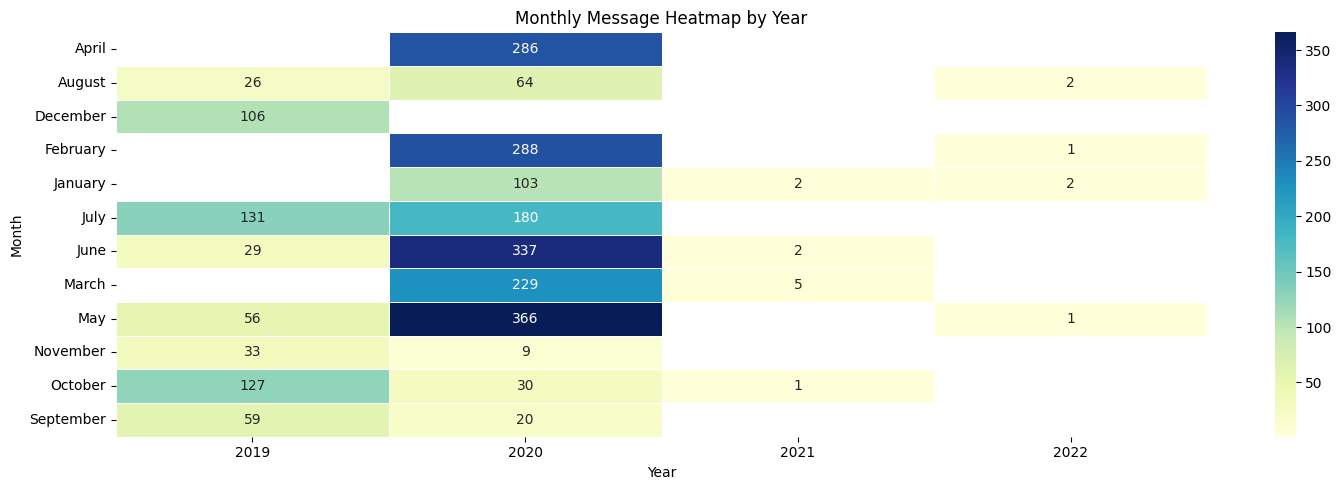

In [29]:
heatmap_data = monthwise_df.pivot_table(index='Month', columns='Year', values='Message', aggfunc='sum')

plt.figure(figsize=(15, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Monthly Message Heatmap by Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.tight_layout()
plt.show()

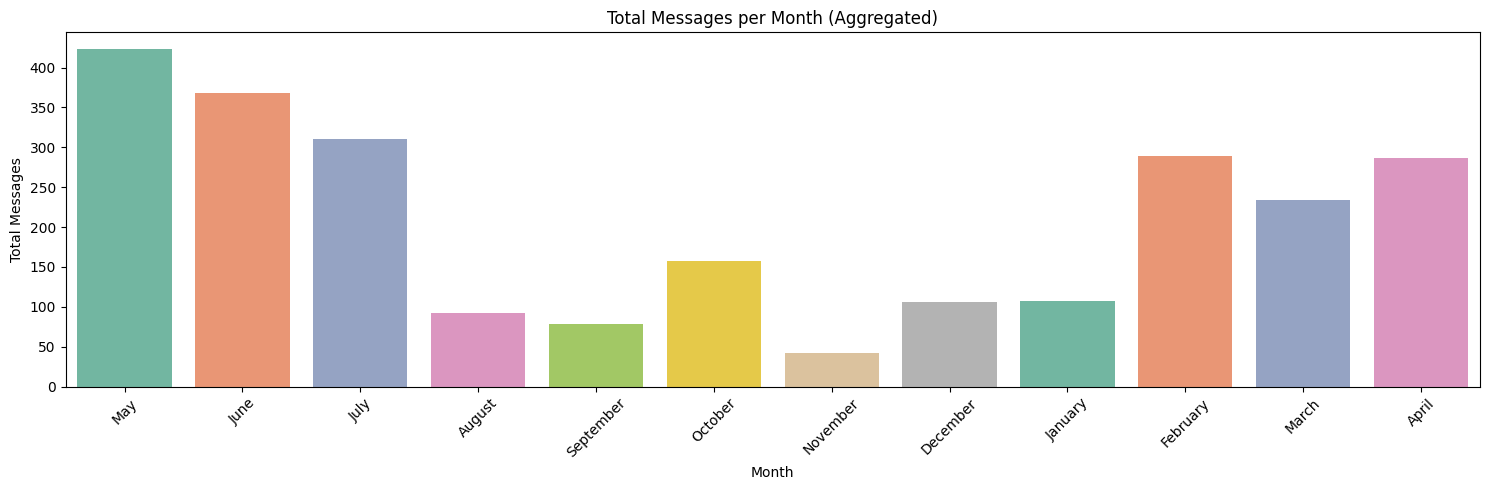

In [30]:
plt.figure(figsize=(15, 5))
month_agg = monthwise_df.groupby('Month', sort=False)['Message'].sum().reset_index()
sns.barplot(data=month_agg, x='Month', y='Message', palette='Set2')
plt.title('Total Messages per Month (Aggregated)')
plt.xlabel('Month')
plt.ylabel('Total Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

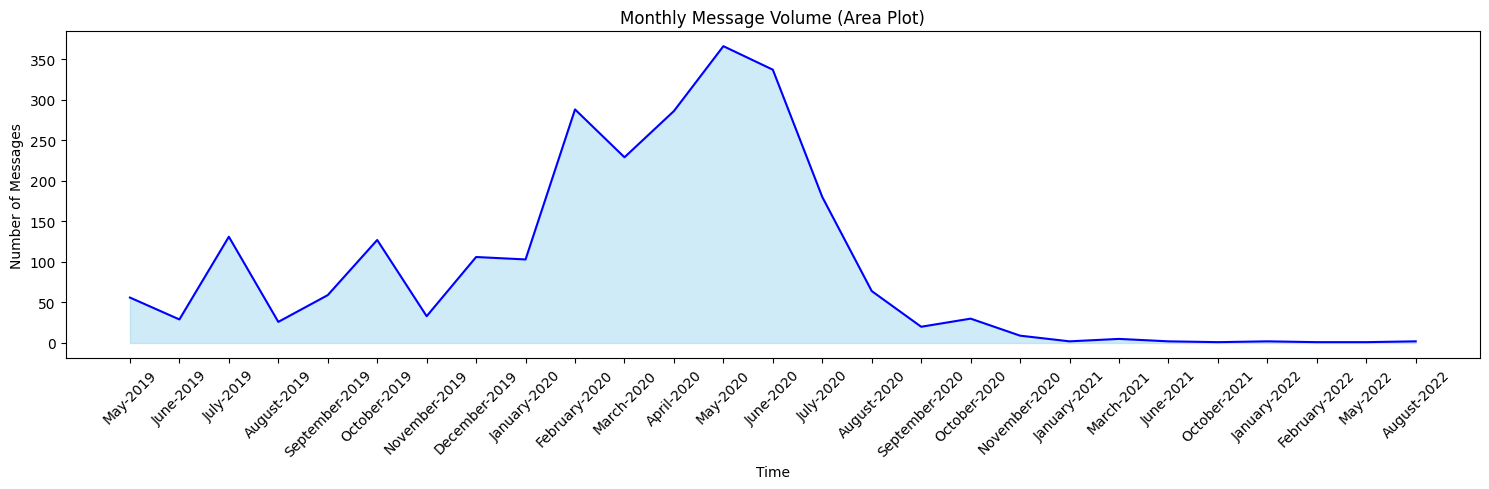

In [31]:
plt.figure(figsize=(15, 5))
plt.fill_between(monthwise_df['Time'], monthwise_df['Message'], color='skyblue', alpha=0.4)
plt.plot(monthwise_df['Time'], monthwise_df['Message'], color='blue')
plt.xticks(rotation=45)
plt.title('Monthly Message Volume (Area Plot)')
plt.xlabel('Time')
plt.ylabel('Number of Messages')
plt.tight_layout()
plt.show()


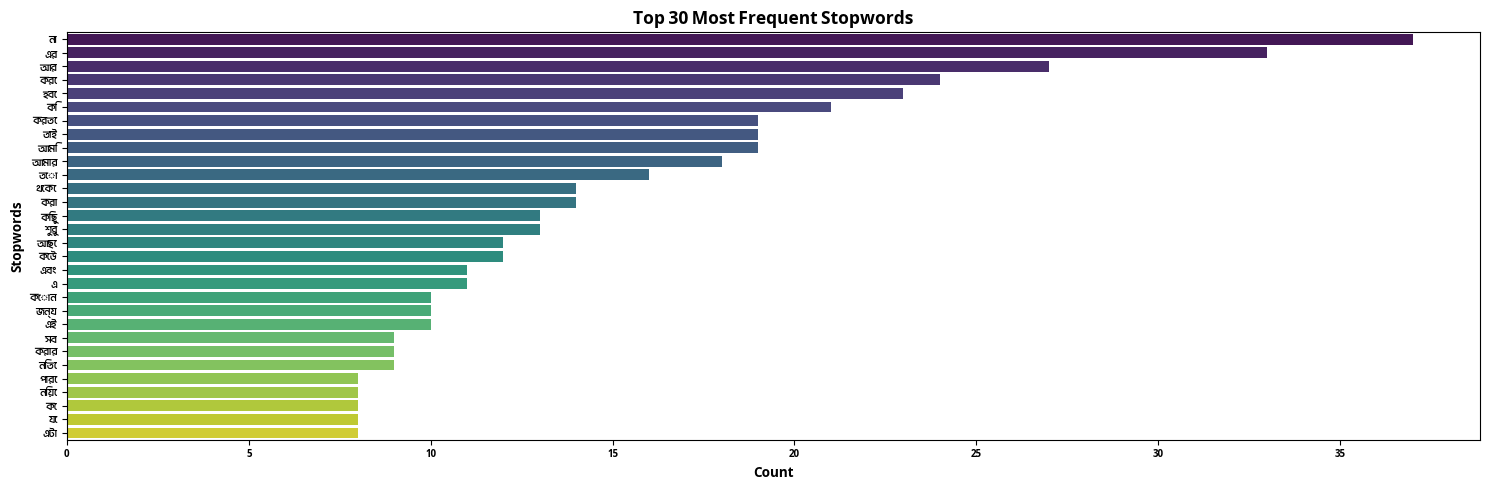

In [32]:
font_path = '/kaggle/input/elegant-and-functional-fonts/Ador Noirrit Web.otf'  # Adjust if needed
font_prop = fm.FontProperties(fname=font_path)
font_prop = fm.FontProperties(fname=font_path)

# Combine all messages into one big text
all_text = ' '.join(new_df['Message'].astype(str))

# Clean text (remove emojis, HTML tags if needed, but you can keep it simple here)
# For example, remove emojis using regex pattern for emojis (if you want, else skip)
emoji_pattern = re.compile("["
         u"\U0001F600-\U0001F64F"  # emoticons
         u"\U0001F300-\U0001F5FF"  # symbols & pictographs
         u"\U0001F680-\U0001F6FF"  # transport & map symbols
         u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
         "]+", flags=re.UNICODE)
all_text = emoji_pattern.sub(r'', all_text)

# Tokenize the text by splitting on whitespace
words = all_text.split()

# Filter only stopwords that appear in the text
stopwords_in_text = [word for word in words if word in stop_words]

# Count frequency of each stopword
stopword_counts = Counter(stopwords_in_text)

# Get top 30 most common stopwords
top_stopwords = stopword_counts.most_common(30)

df_stopwords = pd.DataFrame(top_stopwords, columns=['Stopword', 'Count'])

# Plot bar chart with seaborn and apply font
plt.figure(figsize=(15, 5))
sns.barplot(x='Count', y='Stopword', data=df_stopwords, palette='viridis')

plt.title('Top 30 Most Frequent Stopwords', fontproperties=font_prop, fontsize=18)
plt.xlabel('Count', fontproperties=font_prop, fontsize=14)
plt.ylabel('Stopwords', fontproperties=font_prop, fontsize=14)
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

plt.tight_layout()
plt.show()

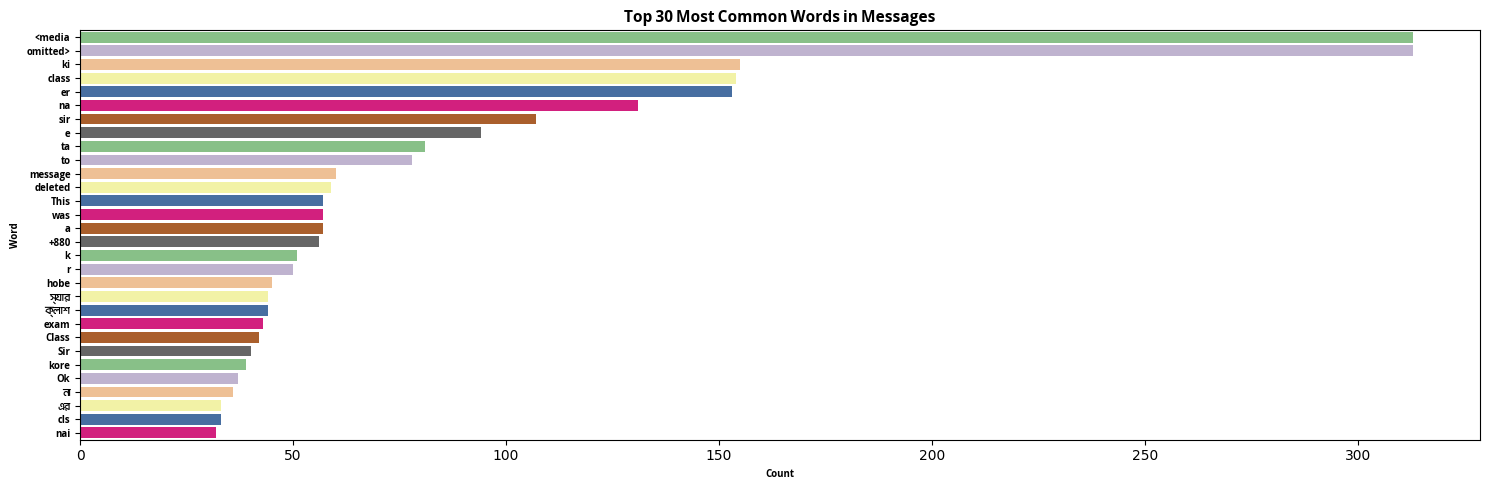

In [33]:
font_path="/kaggle/input/elegant-and-functional-fonts/Ador Noirrit Web.otf"
bangla_font = fm.FontProperties(fname=font_path)

# Tokenize and count all words from cleaned messages
all_words = " ".join(new_df['Message']).split()
word_counts = Counter(all_words)

# Get top 30 most common words
most_common_words = word_counts.most_common(30)
word_df = pd.DataFrame(most_common_words, columns=['Word', 'Count'])

# Plot
plt.figure(figsize=(15, 5))
sns.barplot(y='Word', x='Count', data=word_df,palette="Accent")
plt.title('Top 30 Most Common Words in Messages', fontproperties=bangla_font, fontsize=16)
plt.xlabel('Count', fontproperties=bangla_font)
plt.ylabel('Word', fontproperties=bangla_font)

# Apply font to y-tick labels (words in Bangla)
plt.yticks(fontproperties=bangla_font)

plt.tight_layout()
plt.show()